# 04 – Bidding Evaluation: Newsvendor-Based Wind Power Trading

Dieses Notebook bewertet alle Forecasting-Modelle aus Notebook 03 **ökonomisch**.

## Entscheidungslogik

### Schicht 1 – Gewinnfunktion
pi_t = p_DA,t * b_t + p_reBAP,t * (y_t - b_t)

### Schicht 2 – Newsvendor-Verlustfunktion
L_t = c_under * max(b_t - y_t, 0) + c_over * max(y_t - b_t, 0)

mit:
- c_under = E[max(p_reBAP - p_DA, 0)] → Unterdeckung teuer wenn reBAP > DA
- c_over  = E[max(p_DA - p_reBAP, 0)] → Überdeckung teuer wenn DA > reBAP

### Schicht 3 – Optimales Quantil (klassischer Newsvendor)
tau* = c_under / (c_under + c_over)

### Schicht 4 – Distributionally Robust Bernoulli Newsvendor (Pinson 2022/2023)

| | Ambiguität über | Robuste Lösung |
|---|---|---|
| **Theorem 1** | F̂_omega (Prognoseverteilung) | Wasserstein-verzerrte Quantilfunktion |
| **Theorem 2** | tau_hat (Bernoulli-Parameter) | tau_rob = tau_U (obere CI-Grenze) |

## Zwei Szenarien aus NB03

| Szenario | Features | Erwartung |
|---|---|---|
| **Historical** | Nur SCADA-Lags | Schwächere Forecasts, höherer NV-Loss |
| **NWP** | NWP + SCADA-Lags | Bessere Forecasts, niedrigerer NV-Loss |

## Zentrale Forschungsfragen

1. Ist das Modell mit bestem RMSE auch wirtschaftlich am besten?
2. Bringt die DR-Robustifizierung einen Mehrwert gegenüber dem klassischen Newsvendor?
3. Welche Modelle brauchen ein höheres/niedrigeres tau um Ausreißer abzudecken?
4. Können interpretierbare Modelle (Elastic Net, QR) mit Black-Box-Modellen mithalten?

## 1. Setup und Imports

In [8]:
from __future__ import annotations

from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from IPython.display import display
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

REBAP_DIR    = PROJECT_ROOT / "data" / "raw" / "Daten zu reBAP Preisen"
MARKT_DIR    = PROJECT_ROOT / "data" / "raw" / "Daten zu Marktpreisen"
FORECAST_DIR = PROJECT_ROOT / "results" / "forecasts"
TABLES_DIR   = PROJECT_ROOT / "results" / "tables"
FIGURES_DIR  = PROJECT_ROOT / "results" / "figures"

for d in [TABLES_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

from src.bidding.newsvendor import compute_costs, optimal_quantile, loss, profit

# Okabe-Ito colorblind-friendly palette
COLORS = {
    "actual":     "#000000",
    "elastic_net":"#E69F00",
    "persistence":"#999999",
    "qr":         "#CC79A7",
    "qrf":        "#0072B2",
    "qgb":        "#D55E00",
    "qxgb":       "#56B4E9",
    "violation":  "#FF0000",
}

QUANTILES = [0.10, 0.25, 0.50, 0.75, 0.90]

print("Project root:", PROJECT_ROOT)

Project root: /Users/noahweis/wind_bidding_project


## 2. reBAP-Daten laden

In [9]:
def load_rebap_file(path: Path) -> pd.DataFrame:
    df = pd.read_csv(
        path, sep=";", decimal=",", encoding="utf-8-sig",
        usecols=["Datum", "von", "reBAP unterdeckt", "reBAP ueberdeckt"],
    )
    df["timestamp"] = pd.to_datetime(
        df["Datum"] + " " + df["von"], format="%d.%m.%Y %H:%M", errors="coerce",
    )
    df = df.dropna(subset=["timestamp"]).rename(columns={
        "reBAP unterdeckt": "rebap_under",
        "reBAP ueberdeckt": "rebap_over",
    })
    df["rebap"] = (df["rebap_under"] + df["rebap_over"]) / 2
    return df[["timestamp", "rebap", "rebap_under", "rebap_over"]]

rebap_files = sorted(REBAP_DIR.glob("reBAP *.csv"))
print(f"Gefundene reBAP-Dateien: {len(rebap_files)}")

rebap_raw = pd.concat(
    [load_rebap_file(f) for f in rebap_files], ignore_index=True,
).sort_values("timestamp").reset_index(drop=True)

rebap_hourly = (
    rebap_raw.set_index("timestamp")
    .resample("h")[["rebap", "rebap_under", "rebap_over"]]
    .mean().reset_index()
)

print(f"reBAP stündlich: {rebap_hourly.shape} | {rebap_hourly.timestamp.min().date()} bis {rebap_hourly.timestamp.max().date()}")

Gefundene reBAP-Dateien: 10
reBAP stündlich: (87672, 4) | 2016-01-01 bis 2025-12-31


## 3. EPEX Day-Ahead-Preise laden

In [10]:
def load_smard(path: Path, price_col: str) -> pd.DataFrame:
    df = pd.read_csv(
        path, sep=";", decimal=",", encoding="utf-8-sig",
        usecols=["Datum von", price_col],
        na_values=["-", ""],
    )
    df["timestamp"] = pd.to_datetime(
        df["Datum von"], format="%d.%m.%Y %H:%M", errors="coerce"
    )
    df["da_price"] = pd.to_numeric(df[price_col], errors="coerce")
    return df[["timestamp", "da_price"]].dropna(subset=["timestamp", "da_price"])

da_pre  = load_smard(
    MARKT_DIR / "Gro_handelspreise_201601010000_201810010000_Stunde.csv",
    "DE/AT/LU [€/MWh] Berechnete Auflösungen",
)
da_post = load_smard(
    MARKT_DIR / "Gro_handelspreise_201610010000_202601010000_Stunde.csv",
    "Deutschland/Luxemburg [€/MWh] Berechnete Auflösungen",
)

da_prices = (
    pd.concat([da_pre, da_post])
    .sort_values("timestamp")
    .drop_duplicates("timestamp")
    .reset_index(drop=True)
)

print(f"DA-Preise: {da_prices.shape} | {da_prices.timestamp.min().date()} bis {da_prices.timestamp.max().date()}")
print(f"Mittlerer DA-Preis: {da_prices['da_price'].mean():.2f} EUR/MWh")

DA-Preise: (87662, 2) | 2016-01-01 bis 2025-12-31
Mittlerer DA-Preis: 77.09 EUR/MWh


## 4. Predictions laden (aus NB03 — Single-Day Setup)

Zwei Szenarien werden parallel ausgewertet: `historical` (nur SCADA-Lags) und `nwp` (NWP + SCADA-Lags).

In [11]:
predictions_all = pd.read_csv(
    FORECAST_DIR / "predictions_single_day.csv",
    parse_dates=["timestamp"],
)

print("Alle Predictions Shape:", predictions_all.shape)
print("Szenarien:", predictions_all["scenario"].unique())
print("Fenster:", predictions_all["window_days"].unique())
print("Zieltage:", predictions_all["day_label"].unique())
predictions_all.head()

Alle Predictions Shape: (960, 31)
Szenarien: <StringArray>
['historical', 'nwp']
Length: 2, dtype: str
Fenster: [30 90]
Zieltage: <StringArray>
[      'Winter_calm',    'Winter_average',      'Winter_windy',
    'Fruehling_calm', 'Fruehling_average',   'Fruehling_windy',
       'Sommer_calm',    'Sommer_average',      'Sommer_windy',
      'Herbst_windy']
Length: 10, dtype: str


,timestamp,day_label,window_days,scenario,y_true,persistence_24h,elastic_net,random_forest,gradient_boosting,xgboost,...,qgb_q10,qgb_q25,qgb_q50,qgb_q75,qgb_q90,qxgb_q10,qxgb_q25,qxgb_q50,qxgb_q75,qxgb_q90
0,2018-02-18 00:00:00,Winter_calm,30,historical,668.600000,30.500000,466.770419,535.454434,353.839140,540.02344,...,123.471411,118.729383,249.210395,555.192574,586.831373,133.36902,104.599700,331.42480,656.97180,669.29480
1,2018-02-18 01:00:00,Winter_calm,30,historical,467.000000,131.066667,495.259186,528.536318,306.478594,361.72162,...,129.343815,82.606321,224.729803,513.977544,555.229460,131.48755,59.996666,244.77278,501.92590,559.56494
2,2018-02-18 02:00:00,Winter_calm,30,historical,409.200000,91.500000,488.920844,530.894889,256.581235,335.06845,...,124.849927,77.339532,222.078323,514.305656,555.229460,122.94863,63.839394,241.95297,507.44370,556.88390
3,2018-02-18 03:00:00,Winter_calm,30,historical,226.366667,135.300000,496.388214,557.337352,306.478594,356.19635,...,128.923848,80.389178,227.360495,513.977544,555.229460,125.29205,61.091732,273.92975,494.55032,550.76685
4,2018-02-18 04:00:00,Winter_calm,30,historical,187.766667,250.800000,516.133281,574.745057,312.203881,364.55414,...,67.795064,102.714971,237.156144,530.783786,574.196054,117.31486,81.173420,282.14760,517.07730,527.40990


In [12]:
# Szenario und Fenster auswählen für Haupt-Evaluation
EVAL_SCENARIO    = "nwp"   # "historical" oder "nwp"
EVAL_WINDOW_DAYS = 30

predictions = predictions_all[
    (predictions_all["scenario"]    == EVAL_SCENARIO) &
    (predictions_all["window_days"] == EVAL_WINDOW_DAYS)
].copy().reset_index(drop=True)

print(f"Szenario: {EVAL_SCENARIO} | Fenster: {EVAL_WINDOW_DAYS}d")
print(f"Shape: {predictions.shape}")
print(f"Spalten: {list(predictions.columns)}")

Szenario: nwp | Fenster: 30d
Shape: (240, 31)
Spalten: ['timestamp', 'day_label', 'window_days', 'scenario', 'y_true', 'persistence_24h', 'elastic_net', 'random_forest', 'gradient_boosting', 'xgboost', 'arima', 'quantile_regression_q10', 'quantile_regression_q25', 'quantile_regression_q50', 'quantile_regression_q75', 'quantile_regression_q90', 'qrf_q10', 'qrf_q25', 'qrf_q50', 'qrf_q75', 'qrf_q90', 'qgb_q10', 'qgb_q25', 'qgb_q50', 'qgb_q75', 'qgb_q90', 'qxgb_q10', 'qxgb_q25', 'qxgb_q50', 'qxgb_q75', 'qxgb_q90']


## 5. Predictions mit Preisdaten mergen

In [13]:
df = (
    predictions
    .merge(rebap_hourly, on="timestamp", how="left")
    .merge(da_prices,    on="timestamp", how="left")
)

# Fehlende Preise auffüllen
if df["rebap"].isna().any():
    median_rebap = rebap_hourly["rebap"].median()
    df["rebap"] = df["rebap"].fillna(median_rebap)
    warnings.warn(f"reBAP NaN mit Median ({median_rebap:.2f}) aufgefüllt")

if df["da_price"].isna().any():
    median_da = da_prices["da_price"].median()
    df["da_price"] = df["da_price"].fillna(median_da)
    warnings.warn(f"DA-Preis NaN mit Median ({median_da:.2f}) aufgefüllt")

print("Merged Shape:", df.shape)
df.head()

Merged Shape: (240, 35)


,timestamp,day_label,window_days,scenario,y_true,persistence_24h,elastic_net,random_forest,gradient_boosting,xgboost,...,qgb_q90,qxgb_q10,qxgb_q25,qxgb_q50,qxgb_q75,qxgb_q90,rebap,rebap_under,rebap_over,da_price
0,2018-02-18 00:00:00,Winter_calm,30,nwp,668.600000,30.500000,450.643609,394.993866,359.899495,466.92618,...,603.552864,103.68511,281.76587,372.97958,543.37100,662.24097,41.4050,41.4050,41.4050,34.91
1,2018-02-18 01:00:00,Winter_calm,30,nwp,467.000000,131.066667,409.882402,351.681634,390.979029,401.06030,...,549.598702,121.69752,249.98576,364.05320,482.78810,610.26086,37.3250,37.3250,37.3250,35.68
2,2018-02-18 02:00:00,Winter_calm,30,nwp,409.200000,91.500000,370.736743,319.997075,358.002256,352.95645,...,432.218074,121.69481,222.23454,323.97183,444.35306,515.49830,28.3525,28.3525,28.3525,33.98
3,2018-02-18 03:00:00,Winter_calm,30,nwp,226.366667,135.300000,362.832564,318.582788,370.722755,369.86078,...,438.800836,125.20386,222.07123,326.68840,430.91640,534.16410,42.9250,42.9250,42.9250,33.89
4,2018-02-18 04:00:00,Winter_calm,30,nwp,187.766667,250.800000,281.603895,284.338830,330.398220,315.10422,...,436.358832,86.48282,177.05937,262.03310,396.40964,492.68246,54.8575,54.8575,54.8575,33.83


## 6. Newsvendor-Kostenstruktur

c_under und c_over werden aus dem historischen Zeitraum VOR den Zieltagen geschätzt — kein Data Leakage.

In [14]:
# Frühestes Datum der Zieltage als Cutoff
test_start = df["timestamp"].min() - pd.Timedelta(days=1)

train_prices = (
    rebap_hourly[rebap_hourly["timestamp"] < test_start]
    .merge(da_prices, on="timestamp", how="inner")
)

p_rebap_train = train_prices["rebap"].to_numpy()
p_da_train    = train_prices["da_price"].to_numpy()

c_under, c_over = compute_costs(p_da_train, p_rebap_train)
tau_star = optimal_quantile(c_under, c_over) if (c_under + c_over) > 0 else 0.5

p_rebap = df["rebap"].to_numpy()
p_da    = df["da_price"].to_numpy()
y_true  = df["y_true"].to_numpy()

print(f"Trainingsstunden für Kostenberechnung: {len(train_prices):,}")
print(f"c_under:   {c_under:.4f} EUR/MWh")
print(f"c_over:    {c_over:.4f}  EUR/MWh")
print(f"tau*:      {tau_star:.4f}")
if tau_star > 0.5:
    print("  → Unterdeckung teurer → konservativer bieten")
else:
    print("  → Überdeckung teurer → aggressiver bieten")

Trainingsstunden für Kostenberechnung: 15,358
c_under:   11.7626 EUR/MWh
c_over:    12.0555  EUR/MWh
tau*:      0.4939
  → Überdeckung teurer → aggressiver bieten


## 7. Dynamisches tau* (rollierendes 30-Tage-Fenster)

In [15]:
WINDOW = 30 * 24  # 30 Tage in Stunden

all_prices = (
    rebap_hourly
    .merge(da_prices, on="timestamp", how="inner")
    [["timestamp", "rebap", "da_price"]]
    .sort_values("timestamp")
    .reset_index(drop=True)
)

all_prices["c_under_roll"] = (
    np.maximum(all_prices["rebap"] - all_prices["da_price"], 0)
    .shift(1).rolling(WINDOW, min_periods=168).mean()
)
all_prices["c_over_roll"] = (
    np.maximum(all_prices["da_price"] - all_prices["rebap"], 0)
    .shift(1).rolling(WINDOW, min_periods=168).mean()
)
all_prices["tau_star_dyn"] = (
    all_prices["c_under_roll"] /
    (all_prices["c_under_roll"] + all_prices["c_over_roll"])
).clip(0.01, 0.99)

tau_dyn = (
    df[["timestamp"]]
    .merge(all_prices[["timestamp", "tau_star_dyn"]], on="timestamp", how="left")
    ["tau_star_dyn"]
    .fillna(tau_star)
    .to_numpy()
)

print(f"tau* statisch:   {tau_star:.4f}")
print(f"tau* dyn. Mittel: {tau_dyn.mean():.4f} (Std: {tau_dyn.std():.4f})")
print(f"tau* dyn. Range: [{tau_dyn.min():.4f}, {tau_dyn.max():.4f}]")

tau* statisch:   0.4939
tau* dyn. Mittel: 0.5157 (Std: 0.1089)
tau* dyn. Range: [0.3498, 0.7076]


## 8. DR-BNP Theorem 2 — Konfidenzintervall für tau

In [16]:
s_train_vec = (p_rebap_train > p_da_train).astype(float)
tau_hat_s   = float(s_train_vec.mean())
n_s         = len(s_train_vec)
se_tau      = float(np.sqrt(tau_hat_s * (1.0 - tau_hat_s) / n_s))
z_90        = 1.645
tau_L       = float(np.clip(tau_hat_s - z_90 * se_tau, 0.01, 0.99))
tau_U       = float(np.clip(tau_hat_s + z_90 * se_tau, 0.01, 0.99))

print("=== DR-BNP Theorem 2 ===")
print(f"P(reBAP > pDA) = tau_hat = {tau_hat_s:.4f}")
print(f"SE(tau_hat)              = {se_tau:.6f}  (n = {n_s:,})")
print(f"90%-CI: [tau_L, tau_U]   = [{tau_L:.4f}, {tau_U:.4f}]")
print(f"Robuste Wahl: tau_rob    = tau_U = {tau_U:.4f}")

=== DR-BNP Theorem 2 ===
P(reBAP > pDA) = tau_hat = 0.5584
SE(tau_hat)              = 0.004007  (n = 15,358)
90%-CI: [tau_L, tau_U]   = [0.5518, 0.5650]
Robuste Wahl: tau_rob    = tau_U = 0.5650


## 9. Hilfsfunktionen für Bidding

In [17]:
def evaluate_bid(
    model_name: str,
    bid: np.ndarray,
    y_true: np.ndarray,
    p_da: np.ndarray,
    p_rebap: np.ndarray,
    c_under: float,
    c_over: float,
) -> dict:
    bid      = np.clip(bid, 0, None)
    nv_loss  = loss(bid, y_true, c_under, c_over)
    profits  = profit(bid, y_true, p_da, p_rebap)
    bias     = float(np.mean(bid - y_true))

    return {
        "model":              model_name,
        "mean_profit":        float(np.mean(profits)),
        "total_profit":       float(np.sum(profits)),
        "mean_nv_loss":       float(np.mean(nv_loss)),
        "total_nv_loss":      float(np.sum(nv_loss)),
        "mean_abs_imbalance": float(np.mean(np.abs(y_true - bid))),
        "bias":               bias,
        "bias_pct":           float(bias / np.mean(y_true) * 100),
        "underbid_ratio":     float(np.mean(bid < y_true)),
        "overbid_ratio":      float(np.mean(bid > y_true)),
        "_bid":               bid,
        "_profits":           profits,
        "_nv_loss":           nv_loss,
    }


def get_quantile_bid(model_prefix: str, tau: float) -> np.ndarray:
    """Statisches tau: lineares Interpolieren zwischen verfügbaren Quantilen."""
    exact_col = f"{model_prefix}_q{int(tau * 100):02d}"
    if exact_col in df.columns:
        return np.clip(df[exact_col].to_numpy(), 0, None)
    lower = max((q for q in QUANTILES if q <= tau), default=QUANTILES[0])
    upper = min((q for q in QUANTILES if q >= tau), default=QUANTILES[-1])
    col_l = f"{model_prefix}_q{int(lower*100):02d}"
    col_h = f"{model_prefix}_q{int(upper*100):02d}"
    if lower == upper:
        return np.clip(df[col_l].to_numpy(), 0, None)
    w = (tau - lower) / (upper - lower)
    return np.clip((1-w)*df[col_l].to_numpy() + w*df[col_h].to_numpy(), 0, None)


def get_dynamic_quantile_bid(model_prefix: str, tau_arr: np.ndarray) -> np.ndarray:
    """Dynamisches tau: jede Stunde ihr eigenes tau*_t."""
    q_cols = [f"{model_prefix}_q{int(q*100):02d}" for q in QUANTILES]
    Q = df[q_cols].to_numpy()
    tau_arr = np.clip(tau_arr, QUANTILES[0], QUANTILES[-1])
    bids = np.zeros(len(tau_arr))
    for j in range(len(QUANTILES) - 1):
        lo, hi = QUANTILES[j], QUANTILES[j+1]
        mask = (tau_arr >= lo) & (tau_arr < hi)
        if mask.any():
            w = (tau_arr[mask] - lo) / (hi - lo)
            bids[mask] = (1-w)*Q[mask, j] + w*Q[mask, j+1]
    bids[tau_arr >= QUANTILES[-1]] = Q[tau_arr >= QUANTILES[-1], -1]
    return np.clip(bids, 0, None)


def dr_bnp_thm1_bid(col_prefix: str, tau_hat: float, eps: float) -> np.ndarray:
    """DR-BNP Theorem 1: Wasserstein-robustes Gebot."""
    iqr = (df[f"{col_prefix}_q75"] - df[f"{col_prefix}_q25"]).to_numpy()
    sigma_omega = np.maximum(iqr / 1.35, 1e-6)
    q_nominal = get_quantile_bid(col_prefix, tau_hat)
    q_extreme = df[f"{col_prefix}_q90"].to_numpy() if tau_hat >= 0.5 else df[f"{col_prefix}_q10"].to_numpy()
    weight = np.clip(eps / sigma_omega, 0.0, 1.0)
    return np.clip((1.0 - weight) * q_nominal + weight * q_extreme, 0, None)


results = []

## 10. Point Forecast Bidding

In [18]:
POINT_MODEL_COLS = {
    "Persistence_24h":   "persistence_24h",
    "Elastic_Net":       "elastic_net",
    "Random_Forest":     "random_forest",
    "Gradient_Boosting": "gradient_boosting",
    "XGBoost":           "xgboost",
    "ARIMA":             "arima",
}

print(f"{'Modell':<30} {'Profit':>10} {'NV-Loss':>10} {'Bias':>8} {'Bias%':>7}")
print("-" * 70)

for name, col in POINT_MODEL_COLS.items():
    if col not in df.columns:
        print(f"{name:<30} [nicht vorhanden]")
        continue
    bid = np.clip(df[col].to_numpy(), 0, None)
    r = evaluate_bid(name, bid, y_true, p_da, p_rebap, c_under, c_over)
    results.append(r)
    print(f"{name:<30} {r['mean_profit']:>+10.2f} {r['mean_nv_loss']:>10.2f} {r['bias']:>+8.1f} {r['bias_pct']:>+6.1f}%")

Modell                             Profit    NV-Loss     Bias   Bias%
----------------------------------------------------------------------
Persistence_24h                 +33881.19    3566.21     +0.8   +0.2%
Elastic_Net                     +32447.15    1903.04    +23.5   +7.6%
Random_Forest                   +31687.57    1730.00    +31.0  +10.0%
Gradient_Boosting               +31723.38    1689.19    +28.7   +9.3%
XGBoost                         +32053.88    1665.81    +35.4  +11.5%
ARIMA                           +30172.16    2699.95    +47.2  +15.3%


## 11. Probabilistic Forecast Bidding

Vier Bidding-Strategien werden verglichen:

| Strategie | Bid | Beschreibung |
|---|---|---|
| **Median** | Q_0.5 | Naive Baseline, ignoriert Kostenasymmetrie |
| **tau* statisch** | Q_tau* | Newsvendor-optimal aus Trainingsdaten |
| **tau* dynamisch** | Q_tau*_t | Pinson: rollender 30-Tage-Schätzer |
| **DR-BNP T1** | Wasserstein-verzerrt | Robust gegen Ambiguität in F̂_omega |
| **DR-BNP T2** | Q_tau_U | Robust gegen Ambiguität in tau_hat |

In [19]:
PROB_MODELS = {
    "quantile_regression": "Quantile_Regression",
    "qrf":                  "QRF",
    "qgb":                  "QGB",
    "qxgb":                 "Quantile_XGBoost",
}

EPS_VALUES = [0.10, 0.20, 0.30]

print(f"{'Modell':<45} {'q50':>7} {'tau*_stat':>10} {'tau*_dyn':>9} {'DR-T2':>7}")
print("-" * 85)

for col_prefix, display_name in PROB_MODELS.items():
    # Prüfen ob Quantilspalten vorhanden
    q50_col = f"{col_prefix}_q50"
    if q50_col not in df.columns:
        print(f"{display_name}: [keine Quantilspalten gefunden]")
        continue

    # q50 Median-Bid
    r_q50 = evaluate_bid(f"{display_name} (q50)",
                         get_quantile_bid(col_prefix, 0.5),
                         y_true, p_da, p_rebap, c_under, c_over)
    results.append(r_q50)

    # tau* statisch
    r_stat = evaluate_bid(f"{display_name} (tau*={tau_star:.2f})",
                          get_quantile_bid(col_prefix, tau_star),
                          y_true, p_da, p_rebap, c_under, c_over)
    results.append(r_stat)

    # tau* dynamisch
    r_dyn = evaluate_bid(f"{display_name} (tau* dyn.)",
                         get_dynamic_quantile_bid(col_prefix, tau_dyn),
                         y_true, p_da, p_rebap, c_under, c_over)
    results.append(r_dyn)

    # DR-BNP Theorem 1
    for eps in EPS_VALUES:
        r_dr1 = evaluate_bid(f"{display_name} (DR-T1 eps={eps:.2f})",
                             dr_bnp_thm1_bid(col_prefix, tau_star, eps),
                             y_true, p_da, p_rebap, c_under, c_over)
        results.append(r_dr1)

    # DR-BNP Theorem 2
    r_dr2_l = evaluate_bid(f"{display_name} (DR-T2 tau_L={tau_L:.3f})",
                            get_quantile_bid(col_prefix, tau_L),
                            y_true, p_da, p_rebap, c_under, c_over)
    r_dr2_u = evaluate_bid(f"{display_name} (DR-T2 tau_U={tau_U:.3f})",
                            get_quantile_bid(col_prefix, tau_U),
                            y_true, p_da, p_rebap, c_under, c_over)
    results.extend([r_dr2_l, r_dr2_u])

    print(f"{display_name:<45} {r_q50['mean_nv_loss']:>7.2f} {r_stat['mean_nv_loss']:>10.2f} {r_dyn['mean_nv_loss']:>9.2f} {r_dr2_u['mean_nv_loss']:>7.2f}")

Modell                                            q50  tau*_stat  tau*_dyn   DR-T2
-------------------------------------------------------------------------------------
Quantile_Regression                           1856.86    1852.39   1808.88 1918.30
QRF                                           1748.34    1743.59   1751.01 1813.89
QGB                                           1667.35    1668.02   1600.96 1672.66
Quantile_XGBoost                              1636.36    1636.84   1598.38 1643.47


## 12. Oracle-Benchmark

In [20]:
r_oracle = evaluate_bid(
    "Oracle (perfekt)", y_true.copy(), y_true, p_da, p_rebap, c_under, c_over,
)
results.append(r_oracle)
print(f"Oracle: mean_profit={r_oracle['mean_profit']:+.2f}  mean_nv_loss={r_oracle['mean_nv_loss']:.2f}")

Oracle: mean_profit=+30055.69  mean_nv_loss=0.00


## 13. Ergebnistabelle

In [21]:
summary_cols = [
    "model", "mean_profit", "total_profit",
    "mean_nv_loss", "total_nv_loss",
    "mean_abs_imbalance", "bias", "bias_pct",
    "underbid_ratio", "overbid_ratio",
]

summary = (
    pd.DataFrame([{c: r[c] for c in summary_cols} for r in results])
    .sort_values("mean_nv_loss")
    .reset_index(drop=True)
)

summary.to_csv(TABLES_DIR / "bidding_results_single_day.csv", index=False)
print("Gespeichert: bidding_results_single_day.csv")
display(summary)

Gespeichert: bidding_results_single_day.csv


,model,mean_profit,total_profit,mean_nv_loss,total_nv_loss,mean_abs_imbalance,bias,bias_pct,underbid_ratio,overbid_ratio
0,Oracle (perfekt),30055.690811,7.213366e+06,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,Quantile_XGBoost (tau* dyn.),31672.426867,7.601382e+06,1598.381267,383611.504094,134.413142,16.043613,5.194522,0.420833,0.579167
2,QGB (tau* dyn.),31391.221505,7.533893e+06,1600.961214,384230.691294,134.558067,10.212812,3.306654,0.420833,0.579167
3,Quantile_XGBoost (DR-T2 tau_L=0.552),32084.802523,7.700353e+06,1633.590415,392061.699540,137.456722,23.123326,7.486757,0.412500,0.587500
4,Quantile_XGBoost (DR-T1 eps=0.30),32018.640706,7.684474e+06,1635.539566,392529.495791,137.262696,-5.960107,-1.929734,0.487500,0.504167
5,Quantile_XGBoost (DR-T1 eps=0.20),32019.203183,7.684609e+06,1635.745743,392578.978306,137.281425,-5.844923,-1.892440,0.487500,0.504167
6,Quantile_XGBoost (DR-T1 eps=0.10),32019.765661,7.684744e+06,1635.951920,392628.460820,137.300155,-5.729739,-1.855147,0.487500,0.504167
7,Quantile_XGBoost (q50),32042.844051,7.690283e+06,1636.357535,392725.808315,137.372581,-2.610198,-0.845117,0.475000,0.516667
8,Quantile_XGBoost (tau*=0.49),32029.123802,7.686990e+06,1636.835819,392840.596599,137.376120,-5.587887,-1.809219,0.479167,0.512500
9,Quantile_XGBoost (DR-T2 tau_U=0.565),32095.477902,7.702915e+06,1643.471294,394433.110665,138.366942,29.670636,9.606612,0.404167,0.595833


## 14. Quantil-Robustheits-Analyse

Zeigt für jedes probabilistische Modell den NV-Loss über alle Quantile.
Ein **flaches Minimum** = Modell ist robust gegenüber der tau-Wahl und deckt Ausreißer gut ab.
Ein **scharfes Minimum** = Modell muss sehr genau auf tau* gesetzt werden.

Das erklärt welche Modelle ein höheres/niedrigeres tau brauchen als tau*.

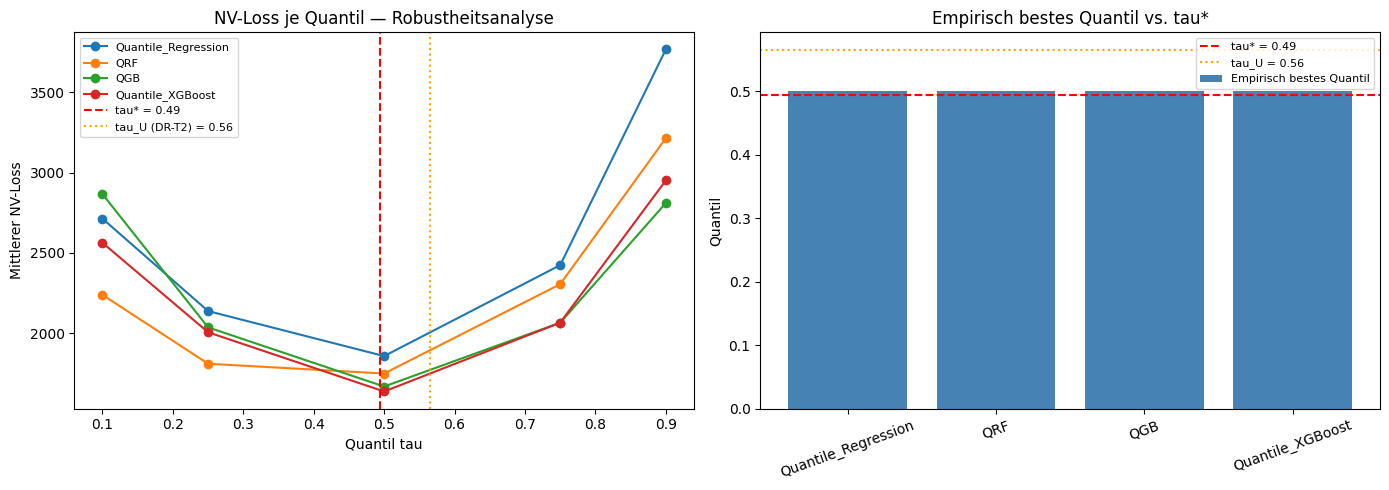


=== Empirisch bestes Quantil pro Modell ===
Modell                                Best tau   Abweichung zu tau*
----------------------------------------------------------------------
Quantile_Regression                       0.50    +0.01 (höher (konservativer))
QRF                                       0.50    +0.01 (höher (konservativer))
QGB                                       0.50    +0.01 (höher (konservativer))
Quantile_XGBoost                          0.50    +0.01 (höher (konservativer))


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Links: NV-Loss pro Quantil pro Modell
ax = axes[0]
best_quantiles = {}

for col_prefix, display_name in PROB_MODELS.items():
    losses = []
    for q in QUANTILES:
        col = f"{col_prefix}_q{int(q*100):02d}"
        if col not in df.columns:
            continue
        bid = np.clip(df[col].to_numpy(), 0, None)
        nv  = float(np.mean(loss(bid, y_true, c_under, c_over)))
        losses.append({"quantile": q, "nv_loss": nv})

    if not losses:
        continue
    loss_df = pd.DataFrame(losses)
    best_q  = loss_df.loc[loss_df["nv_loss"].idxmin(), "quantile"]
    best_quantiles[display_name] = best_q
    ax.plot(loss_df["quantile"], loss_df["nv_loss"], marker="o", label=display_name)

ax.axvline(tau_star, color="red", linestyle="--", linewidth=1.5, label=f"tau* = {tau_star:.2f}")
ax.axvline(tau_U,    color="orange", linestyle=":", linewidth=1.5, label=f"tau_U (DR-T2) = {tau_U:.2f}")
ax.set_xlabel("Quantil tau")
ax.set_ylabel("Mittlerer NV-Loss")
ax.set_title("NV-Loss je Quantil — Robustheitsanalyse")
ax.legend(fontsize=8)

# Rechts: Bestes empirisches Quantil vs. tau*
ax2 = axes[1]
models_bq = list(best_quantiles.keys())
best_qs   = [best_quantiles[m] for m in models_bq]
x = np.arange(len(models_bq))
ax2.bar(x, best_qs, color="steelblue", label="Empirisch bestes Quantil")
ax2.axhline(tau_star, color="red",    linestyle="--", label=f"tau* = {tau_star:.2f}")
ax2.axhline(tau_U,    color="orange", linestyle=":",  label=f"tau_U = {tau_U:.2f}")
ax2.set_xticks(x)
ax2.set_xticklabels(models_bq, rotation=20)
ax2.set_ylabel("Quantil")
ax2.set_title("Empirisch bestes Quantil vs. tau*")
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "quantile_robustness_analysis.png", dpi=300, bbox_inches="tight")
plt.show()

print("\n=== Empirisch bestes Quantil pro Modell ===")
print(f"{'Modell':<35} {'Best tau':>10} {'Abweichung zu tau*':>20}")
print("-" * 70)
for m, bq in best_quantiles.items():
    abw = bq - tau_star
    richtung = "höher (konservativer)" if abw > 0 else "niedriger (aggressiver)" if abw < 0 else "identisch"
    print(f"{m:<35} {bq:>10.2f} {abw:>+8.2f} ({richtung})")

## 15. Grafik: Kumulativer NV-Loss über Zieltage

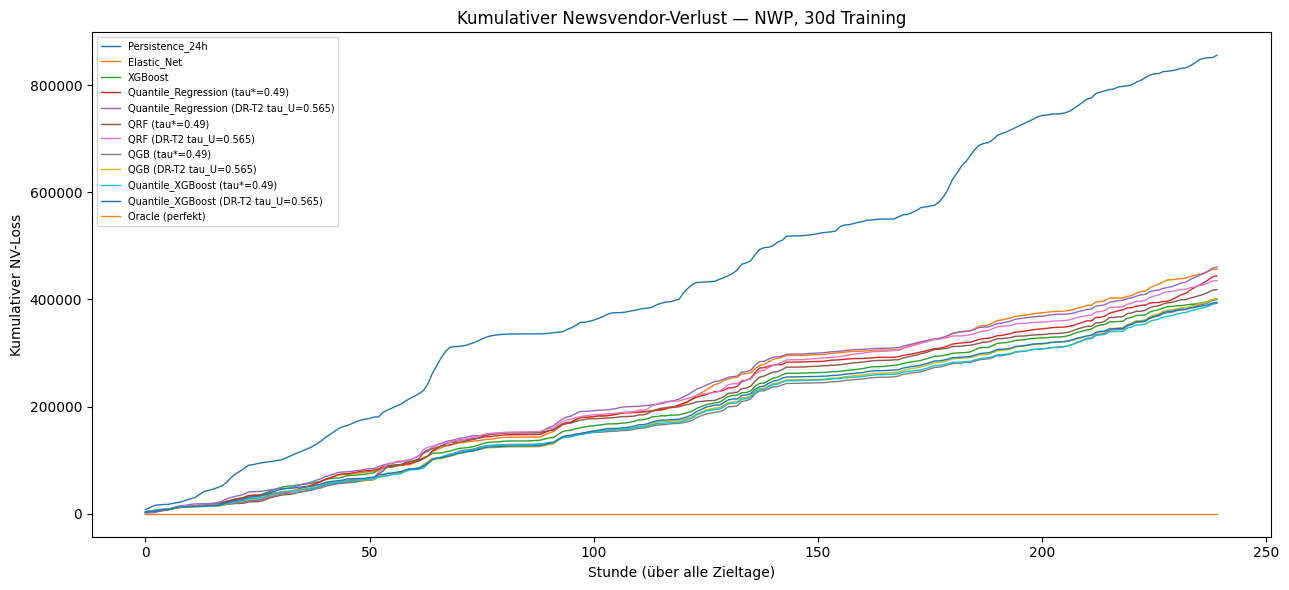

In [23]:
result_map = {r["model"]: r for r in results}

# Auswahl relevanter Modelle
plot_models = [
    "Persistence_24h",
    "Elastic_Net",
    "XGBoost",
]
for col_prefix, display_name in PROB_MODELS.items():
    plot_models.append(f"{display_name} (tau*={tau_star:.2f})")
    plot_models.append(f"{display_name} (DR-T2 tau_U={tau_U:.3f})")
plot_models.append("Oracle (perfekt)")

fig, ax = plt.subplots(figsize=(13, 6))
timestamps = np.arange(len(y_true))  # x-Achse: Index der Zieltag-Stunden

for name in plot_models:
    if name not in result_map:
        continue
    cum_loss = np.cumsum(result_map[name]["_nv_loss"])
    ax.plot(timestamps, cum_loss, label=name, linewidth=1)

ax.set_xlabel("Stunde (über alle Zieltage)")
ax.set_ylabel("Kumulativer NV-Loss")
ax.set_title(f"Kumulativer Newsvendor-Verlust — {EVAL_SCENARIO.upper()}, {EVAL_WINDOW_DAYS}d Training")
ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig(FIGURES_DIR / f"cumulative_nv_loss_{EVAL_SCENARIO}.png", dpi=300, bbox_inches="tight")
plt.show()

## 16. Grafik: Modellvergleich Barplot

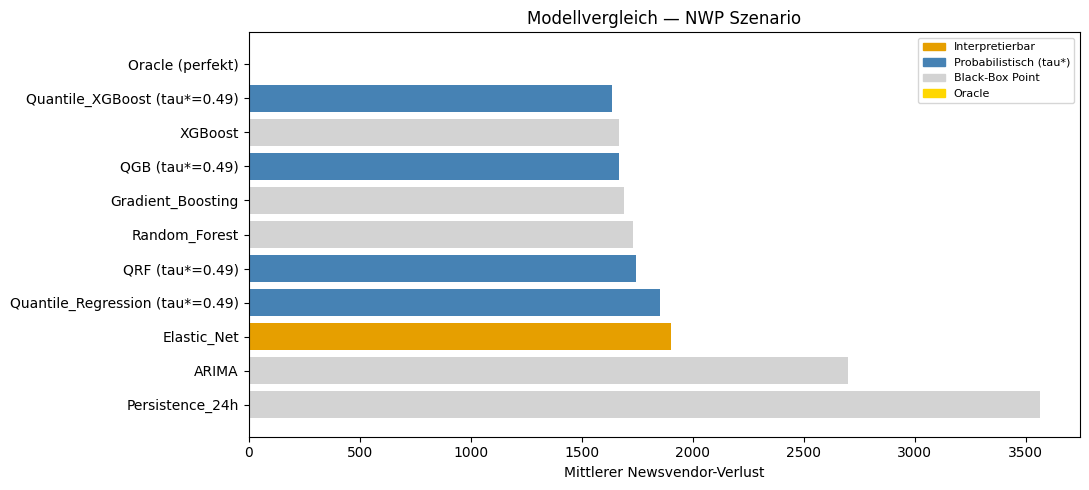

In [24]:
# Nur Hauptstrategien: tau* statisch + Point Forecasts + Oracle
plot_df = summary[
    summary["model"].str.contains(f"tau\\*={tau_star:.2f}") |
    summary["model"].isin(list(POINT_MODEL_COLS.keys()) + ["Oracle (perfekt)"])
].copy()

fig, ax = plt.subplots(figsize=(11, 5))

colors = []
for m in plot_df["model"]:
    if m == "Oracle (perfekt)":
        colors.append("gold")
    elif m in ["Elastic_Net", "Quantile_Regression"]:
        colors.append("#E69F00")  # interpretierbar
    elif "tau*" in m:
        colors.append("steelblue")  # probabilistisch
    else:
        colors.append("lightgray")  # sonstige

ax.barh(plot_df["model"], plot_df["mean_nv_loss"], color=colors)
ax.set_xlabel("Mittlerer Newsvendor-Verlust")
ax.set_title(f"Modellvergleich — {EVAL_SCENARIO.upper()} Szenario")
ax.invert_yaxis()

legend_handles = [
    mpatches.Patch(color="#E69F00",   label="Interpretierbar"),
    mpatches.Patch(color="steelblue", label="Probabilistisch (tau*)"),
    mpatches.Patch(color="lightgray", label="Black-Box Point"),
    mpatches.Patch(color="gold",      label="Oracle"),
]
ax.legend(handles=legend_handles, fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES_DIR / f"model_comparison_{EVAL_SCENARIO}.png", dpi=300, bbox_inches="tight")
plt.show()

## 17. Grafik: Quantilband + Bid vs. Actual pro Zieltag

Zeigt für jeden der 12 Zieltage das probabilistische Prognoseband (q10–q90) des besten Modells
sowie den tau*-Bid gegenüber der tatsächlichen Produktion.
Rote Bereiche = Actual liegt außerhalb des Bands.

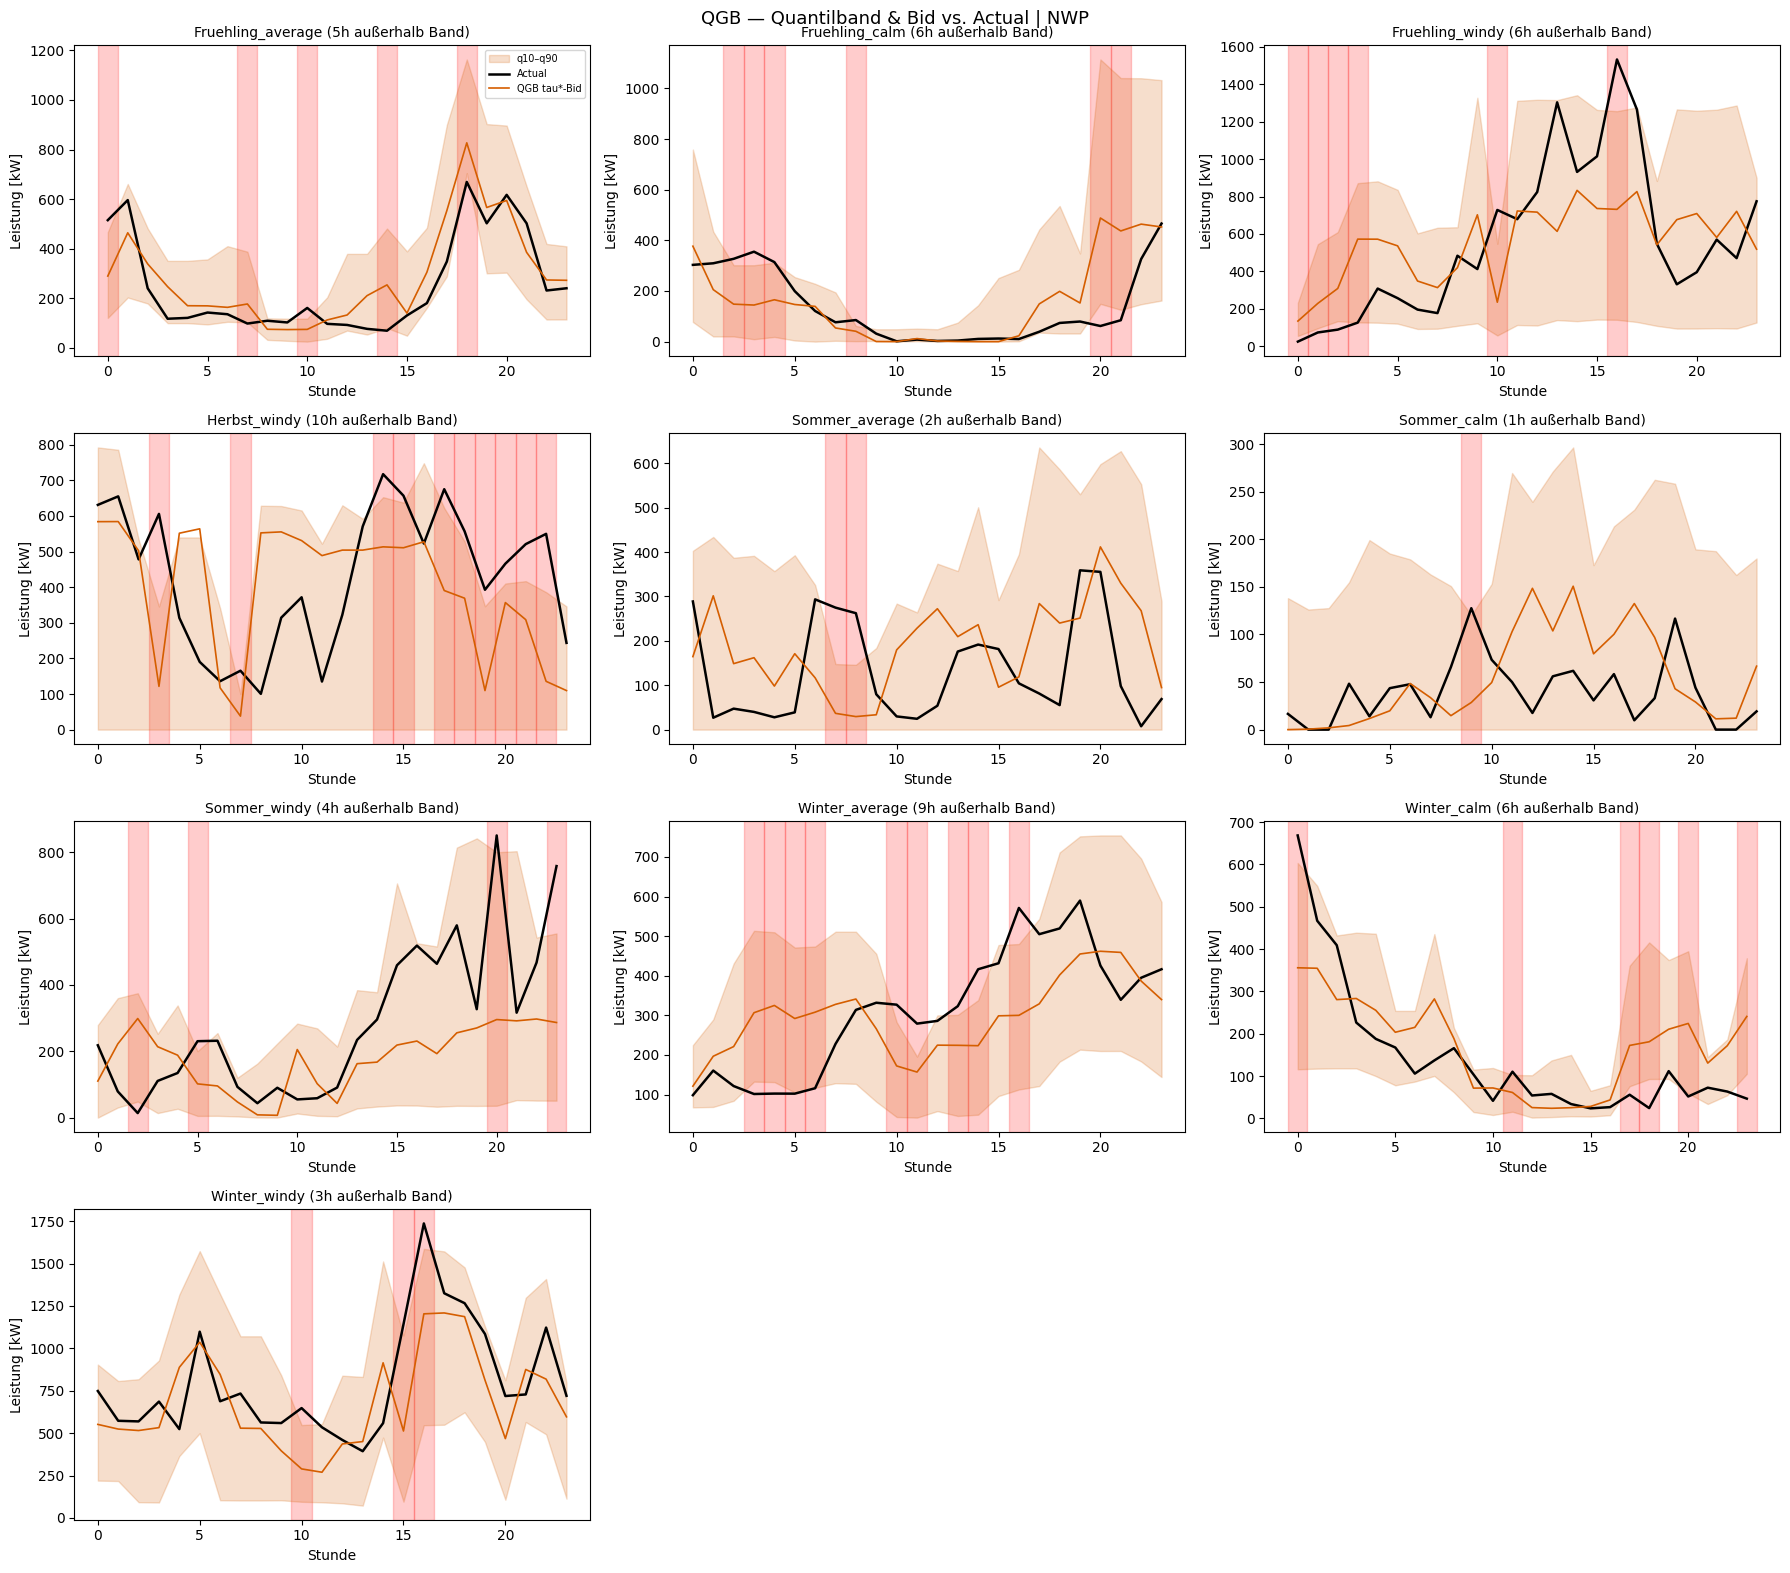

In [25]:
BAND_MODEL_PREFIX = "qgb"   # Modell für Quantilband-Visualisierung
BAND_MODEL_NAME   = "QGB"

day_labels = sorted(df["day_label"].unique())
n_cols = 3
n_rows = (len(day_labels) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4), sharey=False)
axes = axes.flatten()

for i, day_label in enumerate(day_labels):
    ax = axes[i]
    d  = df[df["day_label"] == day_label].sort_values("timestamp")

    if d.empty or f"{BAND_MODEL_PREFIX}_q10" not in d.columns:
        ax.set_title(f"{day_label} (keine Daten)")
        continue

    hours  = range(len(d))
    actual = d["y_true"].values
    q10    = d[f"{BAND_MODEL_PREFIX}_q10"].values
    q90    = d[f"{BAND_MODEL_PREFIX}_q90"].values
    bid    = get_quantile_bid(BAND_MODEL_PREFIX, tau_star)[df["day_label"] == day_label]

    # Rote Markierung wo Actual außerhalb Band
    outside = (actual < q10) | (actual > q90)
    for h in np.where(outside)[0]:
        ax.axvspan(h - 0.5, h + 0.5, color="red", alpha=0.2, zorder=0)

    ax.fill_between(hours, q10, q90, alpha=0.2, color=COLORS["qgb"], label="q10–q90")
    ax.plot(hours, actual, color=COLORS["actual"],     linewidth=1.8, label="Actual")
    ax.plot(hours, bid,    color=COLORS["qgb"],        linewidth=1.2, label=f"{BAND_MODEL_NAME} tau*-Bid")

    n_viol = int(outside.sum())
    ax.set_title(f"{day_label} ({n_viol}h außerhalb Band)", fontsize=10)
    ax.set_xlabel("Stunde")
    ax.set_ylabel("Leistung [kW]")

    if i == 0:
        ax.legend(fontsize=7)

# Leere Subplots ausblenden
for j in range(len(day_labels), len(axes)):
    axes[j].set_visible(False)

fig.suptitle(f"{BAND_MODEL_NAME} — Quantilband & Bid vs. Actual | {EVAL_SCENARIO.upper()}", fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / f"quantile_band_grid_{EVAL_SCENARIO}.png", dpi=250, bbox_inches="tight")
plt.show()

## 18. Szenariovergleich: Historical vs. NWP

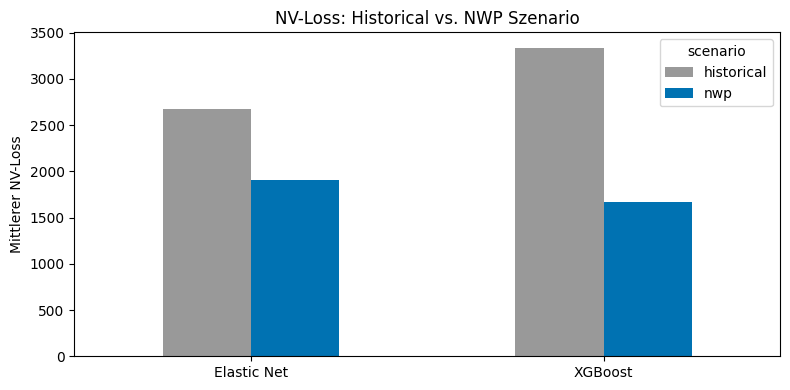

scenario,historical,nwp
model,,
Elastic Net,2676.233665,1903.036279
XGBoost,3335.851814,1665.808337


In [26]:
# NV-Loss für beide Szenarien nebeneinander
scenario_rows = []

for scenario in ["historical", "nwp"]:
    pred_s = predictions_all[
        (predictions_all["scenario"] == scenario) &
        (predictions_all["window_days"] == EVAL_WINDOW_DAYS)
    ].copy()

    if pred_s.empty:
        continue

    pred_s = pred_s.merge(rebap_hourly, on="timestamp", how="left").merge(da_prices, on="timestamp", how="left")
    pred_s["rebap"]    = pred_s["rebap"].fillna(pred_s["rebap"].median())
    pred_s["da_price"] = pred_s["da_price"].fillna(pred_s["da_price"].median())

    y_t   = pred_s["y_true"].to_numpy()
    p_r   = pred_s["rebap"].to_numpy()
    p_d   = pred_s["da_price"].to_numpy()

    for col_name, model_label in [("elastic_net", "Elastic Net"), ("xgboost", "XGBoost")]:
        if col_name not in pred_s.columns:
            continue
        bid = np.clip(pred_s[col_name].to_numpy(), 0, None)
        nv  = float(np.mean(loss(bid, y_t, c_under, c_over)))
        scenario_rows.append({"scenario": scenario, "model": model_label, "mean_nv_loss": nv})

if scenario_rows:
    scen_df = pd.DataFrame(scenario_rows)
    scen_pivot = scen_df.pivot(index="model", columns="scenario", values="mean_nv_loss")

    fig, ax = plt.subplots(figsize=(8, 4))
    scen_pivot.plot(kind="bar", ax=ax, color=["#999999", "#0072B2"])
    ax.set_title("NV-Loss: Historical vs. NWP Szenario")
    ax.set_ylabel("Mittlerer NV-Loss")
    ax.set_xlabel("")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "scenario_nv_loss_comparison.png", dpi=300, bbox_inches="tight")
    plt.show()
    display(scen_pivot)

## 19. Zusammenfassung

In [28]:
best_model  = summary[summary["model"] != "Oracle (perfekt)"].iloc[0]
worst_model = summary[summary["model"] != "Oracle (perfekt)"].iloc[-1]
oracle_r    = result_map["Oracle (perfekt)"]

print("=" * 65)
print("BIDDING EVALUATION — ZUSAMMENFASSUNG")
print("=" * 65)
print(f"Szenario:         {EVAL_SCENARIO.upper()} | Fenster: {EVAL_WINDOW_DAYS}d")
print(f"Zieltage:         {df['day_label'].nunique()} Tage x 24h = {len(y_true)} Stunden")
print()
print(f"tau* (statisch):  {tau_star:.4f}")
print(f"tau* (dyn. Mittel): {tau_dyn.mean():.4f}")
print(f"tau_U (DR-T2):    {tau_U:.4f}")
print(f"c_under:          {c_under:.4f} EUR/MWh")
print(f"c_over:           {c_over:.4f}  EUR/MWh")
print()
print(f"Bestes Modell:    {best_model['model']}")
print(f"  NV-Loss:        {best_model['mean_nv_loss']:.4f}")
print(f"  Bias:           {best_model['bias']:+.1f} kW ({best_model['bias_pct']:+.1f}%)")
print()
print(f"Schlechtestes:    {worst_model['model']}")
print(f"  NV-Loss:        {worst_model['mean_nv_loss']:.4f}")
print()
print(f"Oracle:           NV-Loss={oracle_r['mean_nv_loss']:.4f}")
print()
print("Empirisch bestes Quantil pro Modell:")
for m, bq in best_quantiles.items():
    abw = bq - tau_star
    print(f"  {m:<35} Q_{bq:.2f}  (Abweichung: {abw:+.2f})")
print()
print("Vollständige Ergebnistabelle:")
display(summary[["model", "mean_nv_loss", "bias", "bias_pct", "underbid_ratio", "overbid_ratio"]].head(15))

BIDDING EVALUATION — ZUSAMMENFASSUNG
Szenario:         NWP | Fenster: 30d
Zieltage:         10 Tage x 24h = 240 Stunden

tau* (statisch):  0.4939
tau* (dyn. Mittel): 0.5157
tau_U (DR-T2):    0.5650
c_under:          11.7626 EUR/MWh
c_over:           12.0555  EUR/MWh

Bestes Modell:    Quantile_XGBoost (tau* dyn.)
  NV-Loss:        1598.3813
  Bias:           +16.0 kW (+5.2%)

Schlechtestes:    Persistence_24h
  NV-Loss:        3566.2095

Oracle:           NV-Loss=0.0000

Empirisch bestes Quantil pro Modell:
  Quantile_Regression                 Q_0.50  (Abweichung: +0.01)
  QRF                                 Q_0.50  (Abweichung: +0.01)
  QGB                                 Q_0.50  (Abweichung: +0.01)
  Quantile_XGBoost                    Q_0.50  (Abweichung: +0.01)

Vollständige Ergebnistabelle:


,model,mean_nv_loss,bias,bias_pct,underbid_ratio,overbid_ratio
0,Oracle (perfekt),0.000000,0.000000,0.000000,0.000000,0.000000
1,Quantile_XGBoost (tau* dyn.),1598.381267,16.043613,5.194522,0.420833,0.579167
2,QGB (tau* dyn.),1600.961214,10.212812,3.306654,0.420833,0.579167
3,Quantile_XGBoost (DR-T2 tau_L=0.552),1633.590415,23.123326,7.486757,0.412500,0.587500
4,Quantile_XGBoost (DR-T1 eps=0.30),1635.539566,-5.960107,-1.929734,0.487500,0.504167
5,Quantile_XGBoost (DR-T1 eps=0.20),1635.745743,-5.844923,-1.892440,0.487500,0.504167
6,Quantile_XGBoost (DR-T1 eps=0.10),1635.951920,-5.729739,-1.855147,0.487500,0.504167
7,Quantile_XGBoost (q50),1636.357535,-2.610198,-0.845117,0.475000,0.516667
8,Quantile_XGBoost (tau*=0.49),1636.835819,-5.587887,-1.809219,0.479167,0.512500
9,Quantile_XGBoost (DR-T2 tau_U=0.565),1643.471294,29.670636,9.606612,0.404167,0.595833
